# Load maps from Meg and run the iterative lensing reconstruction from Lensit

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np 
from matplotlib import pyplot as pl
import lensit as li
from lensit.ffs_covs.ffs_cov import cl_inverse as cli
from lensit.ffs_iterators.ffs_iterator import ffs_iterator_pertMF
from lensit.misc.misc_utils import gauss_beam
from lensit.qcinv import ffs_ninv_filt_ideal, chain_samples
from lensit.ffs_covs import ell_mat, ffs_cov
from lensit import misc, qcinv, get_ellmat

import os

pbs.py : LOCAL setup OK, rank 0 in 1
Using finufft


In [3]:
w = lambda ell : ell ** 2 * (ell + 1.) ** 2 /2./np.pi * 1e7
f = lambda ell : ell * (ell + 1.) /2./np.pi

## Meg maps 
- HDres = LDres
- LDres = 2^9 = 512
- phi and unlensed cmb are stored in fourier space, without any filtering in lmax -> convert it with lib_qlm to make the lmax filtering 


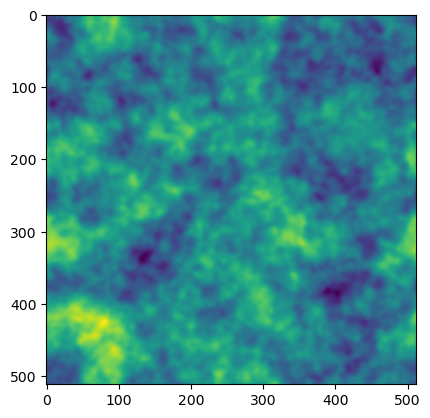

In [4]:
data_input = np.load("/Users/louis/code/CMB_Project_Meg/results/sim_maps.npz")
data_rec = np.load("/Users/louis/code/CMB_Project_Meg/results/bandpass_6000_full.npz")
data_rec_4000 = np.load("/Users/louis/code/CMB_Project_Meg/results/bandpass_4000_full.npz")

pl.imshow(data_input['f_lensed'].reshape(512, 512))

In [5]:
tmap = data_input['f_lensed'].reshape(512, 512)

In [6]:
print(data_input.files)

['Cf_diag', 'theta_pix_arcmin', 'dtype', 'f_lensed', 'Cl_phi', 'phi', 'Cl_n', 'f_unlensed', 'ell', 'pol', 'Cn_diag', 'Cphi_diag', 'Cl_TT', 'seed', 'Nside']


In [7]:
print(data_rec.files)

['Cf_diag', 'Cn_diag', 'phi_true', 'phi_map', 'theta_pix_arcmin', 'bandpass', 'f_lensed', 'history', 'Cl_phi', 'f_map', 'Cphi_diag', 'dtype', 'Cl_noise', 'Cl_TT', 'seed', 'Nside', 'f_unlensed', 'ell', 'pol']


In [8]:
print(data_rec_4000.files)

['Cf_diag', 'pol', 'Cn_diag', 'phi_true', 'phi_map', 'theta_pix_arcmin', 'bandpass', 'history', 'phi_marg', 'Cl_phi', 'f_map', 'Cphi_diag', 'dtype', 'Cl_noise', 'Cl_TT', 'seed', 'Nside', 'f_unlensed', 'ell', 'Cl_unlensed_TT']


Use input Cls from Meg in the filters 

In [9]:
cl_pp_meg = np.zeros(data_input['ell'][-1]+1)
cl_pp_meg[data_input['ell']] = data_input['Cl_phi']

# Unlensed CMB TT only in data rec 4000 ? 
cl_tt_meg_unl = np.zeros(data_rec_4000['ell'][-1]+1)
cl_tt_meg_unl[data_rec_4000['ell']] = data_rec_4000['Cl_unlensed_TT'] 

cl_tt_meg_len = np.zeros(data_rec['ell'][-1]+1)
cl_tt_meg_len[data_rec['ell']] = data_rec['Cl_TT']

cls_n_tt_meg = np.zeros(data_input['ell'][-1]+1)
cls_n_tt_meg[data_input['ell'][:len(data_input['Cl_n'])]] = data_input['Cl_n']

In [10]:
li_fidcls = li.get_fidcls(ellmax_sky=8000)

cls_unl = {'pp':cl_pp_meg,
#           'tt':cl_tt_meg_unl, 
           'tt':li_fidcls[0]['tt'],
          'ee':li_fidcls[0]['ee'], 
          'te':li_fidcls[0]['ee'], 
          'bb':li_fidcls[0]['bb'], 
          }

cls_len = {'tt':cl_tt_meg_len,
            'ee':li_fidcls[1]['ee'], 
          'te':li_fidcls[1]['ee'], 
          'bb':li_fidcls[1]['bb'], 
          }


cls_noise ={'t':cls_n_tt_meg}


In [11]:
libdir = lambda LD_res, HD_res, ellmin, ellmax, suffix: os.path.join('TEMP', 'meg_maps',  'LD%sHD%s' % (LD_res, HD_res), 'lmin%slmax%s' % (ellmin, ellmax), suffix)

In [14]:
# physical size of maps is 2^H * 0.74 arcmin, 
# where theta_res =  \sqrt(4pi) / 2^14 * 180*60/np.pi arcmin \sim  0.74 arcmin
# number of pixels is 2^L
LD_res = 9 
HD_res = 9 
ellmat = get_ellmat(LD_res, HD_res=HD_res) # Library to handle Fourier modes on the flat sky 

suffix = 'cmbs4'

# for now we only use T maps
typ = 'T'

# Maxmimum and minimum multipoles used in the CMB maps for the reconstruction 
ellmin = 10 
ellmax = 6000

# Beam of the experiment
Beam_FWHM_amin = 1
cl_transf = gauss_beam(Beam_FWHM_amin / 60. * np.pi / 180., lmax=ellmax)


# QE filtering uses the full colored oise Cl, 
# but MAP isotropic filtering is done assuming white noise
NlevT_filt = 1 # muK amin 
NlevP_filt = NlevT_filt * np.sqrt(2)


# lib_alm instance (see *lensit.ffs_covs.ell_mat*) containing mode filtering and flat-sky patch info 
lib_alm = ell_mat.ffs_alm_pyFFTW(get_ellmat(LD_res, HD_res=HD_res),
                    filt_func=lambda ell: (ell >= ellmin) & (ell <= ellmax))

# Library for flat-sky calculations of various lensing biases, responses, etc. in a idealized, isotropic case
lib_dir = libdir(LD_res, HD_res, ellmin, ellmax, suffix)
isocov = ffs_cov.ffs_diagcov_alm(lib_dir, lib_alm, cls_unl, cls_len, cl_transf, cls_noise)

print(" I will be using data from ell=%s to ell=%s only"%(isocov.lib_datalm.ellmin, isocov.lib_datalm.ellmax))
print(" The sky band-limit is ell=%s"%(isocov.lib_skyalm.ellmax))


 I will be using data from ell=56 to ell=6000 only
 The sky band-limit is ell=6000


In [15]:
# Get the QE
# We now build the quadratic estimator
# We use lensed CMB spectra in the weights.
lib_qlm = isocov.lib_skyalm #: This means we will reconstruct the lensing potential for all unlensed sky modes.


datalms = np.array([isocov.lib_datalm.map2alm(tmap)]) 
plm_qe = 0.5 * isocov.get_qlms(typ,  isocov.get_iblms(typ, datalms, use_cls_len=True)[0], lib_qlm, 
                         use_cls_len=True)[0]

# Normalisation 
N0len =  isocov.get_N0cls(typ, lib_qlm, use_cls_len=True)[0]
lib_qlm.almxfl(plm_qe, N0len, inplace=True)



     [00:00:00]  (total [00:00:00])   get_qlms::mult with len Pmat  
     [00:00:00]  (total [00:00:00])   get_qlms::cartesian gradients  
     [00:00:00]  (total [00:00:00])   get_qlms::rotation to phi Omega  


In [16]:
# We use as starting point of the iteration the Wiener filtered QE

# Normalization and Wiener-filtering:
# H0len =  cli(isocov.get_N0cls(typ, lib_qlm, use_cls_len=True)[0])
cpp_prior = cls_unl['pp'][:lib_qlm.ellmax+1]
plm0 = lib_qlm.almxfl(plm_qe, cpp_prior * cli(cpp_prior + N0len), inplace=False)

# Initial likelihood curvature guess. We use here N0 as calculated with unlensed CMB spectra:
H0unl =  cli(isocov.get_N0cls(typ, lib_qlm, use_cls_len=False)[0])


In [17]:
"""Gets an iterator instance from the input data maps, lensing map starting point,
likelihood curvature guess and choice of filtering parameters (ideally close to those of the data).
"""

# Anisotropic filtering instance, with unlensed CMB spectra as inputs. Delfections will be added by the iterator.
filt = ffs_ninv_filt_ideal.ffs_ninv_filt(lib_alm, lib_alm, cls_unl, cl_transf, NlevT_filt, NlevP_filt)

# Description of the multi-grid chain to use: (here the simplest, diagonal pre-conditioner) 
chain_descr = chain_samples.get_isomgchain(filt.lib_skyalm.ellmax,filt.lib_datalm.shape,
                                                    tol=1e-6,iter_max=200)

opfilt =  qcinv.opfilt_cinv_noBB
opfilt._type = typ

# With all this now in place, we can build the iterator instance:
itlib = ffs_iterator_pertMF(lib_dir, typ, filt, datalms, lib_qlm, 
          plm0, H0unl,  cls_unl['pp'], chain_descr=chain_descr, opfilt=opfilt, verbose=True)

 I see t 1
 I see q 1.4142135623730951
 I see u 1.4142135623730951
ffs iterator : This is 0 trying to setup TEMP/meg_maps/LD9HD9/lmin10lmax6000/cmbs4
++ ffs_<class 'type'> masked iterator : setup OK


In [32]:
# Performs the iterations 
itmax = 10
for i in range(itmax+1):
    itlib.iterate(i, 'p')

rank 0 caching displacement comp. for it. 9 for key p
rank 0, ffs_deflect::buffers size, chk_shape (30, 31) [512 512]
rank 0 inverting displacement it. 9 for key p
NR iter 1: max. increment size in NR deflection inverse 6.43e-01 amin
           mean x, y rms increment : 2.26e-02, 2.20e-02 amin
NR iter 2: max. increment size in NR deflection inverse 1.02e-02 amin
           mean x, y rms increment : 2.68e-05, 2.60e-05 amin
NR iter 3: max. increment size in NR deflection inverse 7.48e-06 amin
           mean x, y rms increment : 1.07e-08, 1.05e-08 amin
 [00:00:00] ffs_deflect::calculating inverse displ. field > 00%
rank 0, ffs_deflect::buffers size, chk_shape (30, 31) [512 512]
rank 0 caching TEMP/meg_maps/LD9HD9/lmin10lmax6000/cmbs4/qlm_gradPpri_it009.npy
rank 0 caching TEMP/meg_maps/LD9HD9/lmin10lmax6000/cmbs4/qlm_gradPdet_it009.npy
rank 0, ffs_deflect::buffers size, chk_shape (30, 31) [512 512]
rank 0, ffs_deflect::buffers size, chk_shape (30, 31) [512 512]
rank 0 loading TEMP/meg_map

By default the filter removes the monopole, but it seems it is present in the phi of Meg

In [19]:
lib_datalm = lib_alm
ellmat = lib_datalm.ell_mat
lib_qlm_full = ell_mat.ffs_alm(ellmat, filt_func=lambda ell: ell >= 0)

The lib_qlm selects only kx,ky modes that are included in the lmax radius 


In [20]:
# lib_qlm_full.udgrade(lib_qlm, data['phi'])
plm_input = lib_qlm.udgrade(lib_qlm_full, data_input['phi']) * lib_qlm.fac_rfft2alm

[]

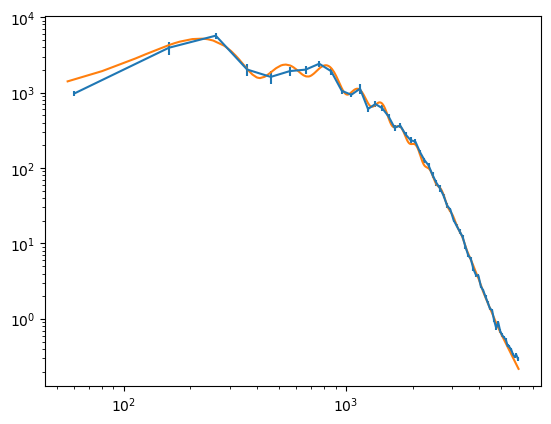

In [21]:
ell, = np.where(lib_datalm.get_Nell()[:6000+1])
# pl.plot(ell, f(ell)*lib_datalm.map2cl(tmap)[ell])

bnd_cl = lambda cl : misc.misc_utils.binned(cl, ell, bl, bu, w=f, return_err=True)

edges = np.arange(10, 6000+100, 100)
bl = edges[:-1];bu = edges[1:] 
cl, err = bnd_cl(lib_datalm.map2cl(tmap))

pl.errorbar(0.5 * bl + 0.5 * bu, cl , yerr=err)
pl.plot(ell, f(ell)*cls_len['tt'][ell])
pl.loglog()

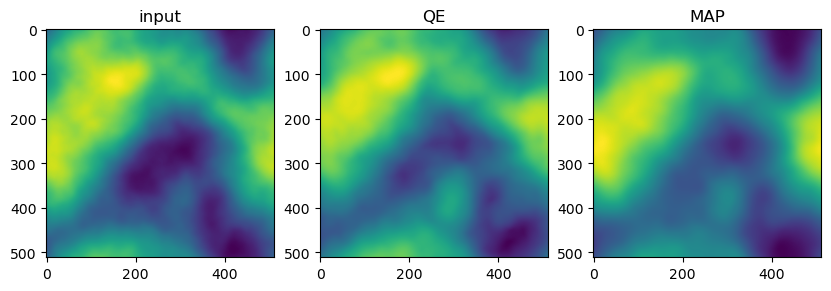

In [55]:
fig, axs = pl.subplots(1, 3, figsize=(10, 6))

for plm, ax, title in zip([plm_input, itlib.get_Plm(0, 'p'), itlib.get_Plm(itmax, 'p')], axs, ['input', 'QE', 'MAP']):
    pmap = itlib.lib_qlm.alm2map(plm)
    
    ax.imshow(pmap)
    ax.set_title(title)

In [64]:
# Exports

# np.savez(f'llrec_lmin{ellmin}_lmax{ellmax}', 
#          plm_qe=plm_qe, plm_it=itlib.get_Plm(itmax, 'p'), 
#          phi_qe=itlib.lib_qlm.alm2map(plm_qe), 
#          phi_it=itlib.lib_qlm.alm2map(itlib.get_Plm(itmax, 'p'))
#         )

# npzfile = np.load(f'llrec_lmin{ellmin}_lmax{ellmax}.npz')
# npzfile.files

[]

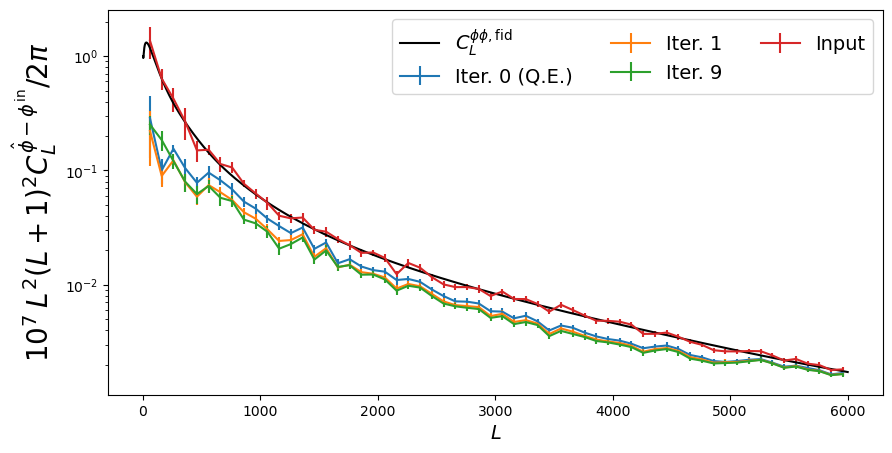

In [39]:
lmax_qlm = 6000
ell, = np.where(itlib.lib_qlm.get_Nell()[:lmax_qlm+1])
edges = np.arange(10, lmax_qlm+100, 100)
bl = edges[:-1];bu = edges[1:] 
bnd_cl = lambda cl : misc.misc_utils.binned(cl, ell, bl, bu, w=w, return_err=True)


cl_in = itlib.lib_qlm.alm2cl(plm_input)

pl.figure(figsize= (10,5))

for it in [0, 1, 9]:
    cl, err = bnd_cl(itlib.lib_qlm.alm2cl(itlib.get_Plm(it, 'p') - plm_input))
#     cl, err = bnd_cl(itlib.lib_qlm.alm2cl(itlib.get_Plm(it, 'p')))
    
    
    pl.errorbar(0.5 * bl + 0.5 * bu, cl , yerr=err, label='Iter. %s'%it + (it == 0) * ' (Q.E.)')
    
cl_input, err_input = bnd_cl(itlib.lib_qlm.alm2cl(plm_input))    
pl.errorbar(0.5 * bl + 0.5 * bu, cl_input , yerr=err_input, label='Input')


# pl.plot(ell, li.get_fidcls()[0]['pp'][ell] * w(ell), c='k', label=r'$C_L^{\phi\phi, \rm fid}$')

pl.plot(data_input['ell'][:lmax_qlm], data_input['Cl_phi'][:lmax_qlm] * w(data_input['ell'][:lmax_qlm]), c='k', label=r'$C_L^{\phi\phi, \rm fid}$')

pl.ylabel(r'$10^7\: L^2(L + 1)^2 C^{\hat \phi - \phi^{\rm in}}_L /2 \pi$', fontsize=20)
pl.xlabel(r'$L$', fontsize=14)
pl.legend(ncol=3, fontsize=14)
pl.semilogy()

<>:14: DeprecationWarning: invalid escape sequence '\e'
<>:14: DeprecationWarning: invalid escape sequence '\e'
/var/folders/k2/pz579q490y94_cj44cpv_5l80000gn/T/ipykernel_91610/1412039603.py:14: DeprecationWarning: invalid escape sequence '\e'
  pl.errorbar(0.5 * bl + 0.5 * bu, cl_input , yerr=err_input, label='$C_\ell^{\phi^{input}, \phi^{input}}$')


[]

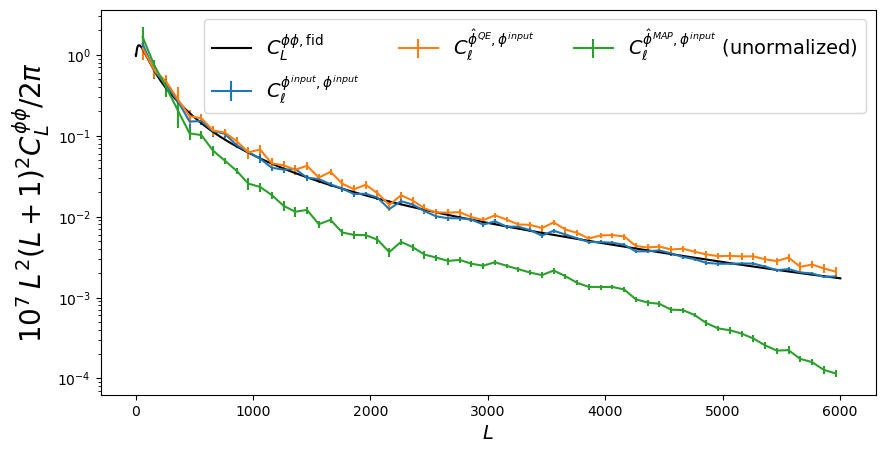

In [40]:
lmax_qlm = 6000
ell, = np.where(itlib.lib_qlm.get_Nell()[:lmax_qlm+1])
edges = np.arange(10, lmax_qlm+100, 100)
bl = edges[:-1];bu = edges[1:] 
bnd_cl = lambda cl : misc.misc_utils.binned(cl, ell, bl, bu, w=w, return_err=True)


cl_in = itlib.lib_qlm.alm2cl(plm_input)

pl.figure(figsize= (10,5))


cl_input, err_input = bnd_cl(itlib.lib_qlm.alm2cl(plm_input))    
pl.errorbar(0.5 * bl + 0.5 * bu, cl_input , yerr=err_input, label='$C_\ell^{\phi^{input}, \phi^{input}}$')


cl, err = bnd_cl(itlib.lib_qlm.alm2cl(plm_qe , plm_input))
pl.errorbar(0.5 * bl + 0.5 * bu, cl , yerr=err, label=r'$C_\ell^{\hat \phi^{QE}, \phi^{input}}$')


cl, err = bnd_cl(itlib.lib_qlm.alm2cl(itlib.get_Plm(itmax, 'p'),  plm_input))
pl.errorbar(0.5 * bl + 0.5 * bu, cl , yerr=err, label=r'$C_\ell^{\hat \phi^{MAP}, \phi^{input}}$ (unormalized)')


pl.plot(data_input['ell'][:lmax_qlm], data_input['Cl_phi'][:lmax_qlm] * w(data_input['ell'][:lmax_qlm]), c='k', label=r'$C_L^{\phi\phi, \rm fid}$')

pl.ylabel(r'$10^7\: L^2(L + 1)^2 C^{\phi\phi}_L /2 \pi$', fontsize=20)
pl.xlabel(r'$L$', fontsize=14)
pl.legend(ncol=3, fontsize=14)
pl.semilogy()

In [42]:
meg_qe = np.array([
    [222.97297297297297, 0.8625592417061612],
    [527.027027027027, 0.7030015797788309],
    [820.9459459459459, 0.5971563981042654],
    [1423.9864864864865, 0.48973143759873616],
    [1728.0405405405406, 0.4834123222748815],
    [2006.7567567567567, 0.4565560821484992],
    [2614.864864864865, 0.44075829383886256],
    [2944.2567567567567, 0.45339652448657186],
    [3217.9054054054054, 0.48973143759873616],
    [3836.1486486486488, 0.4423380726698263],
    [4140.2027027027025, 0.4597156398104265],
    [4423.986486486487, 0.39652448657188],
    [5032.094594594594, 0.325434439178515],
    [5320.945945945946, 0.30963665086887837],
    [5604.72972972973, 0.24960505529225907],
    [6000, 0.2148499210110585],
]).T

meg_map = np.array([
    [212.83783783783784, 0.8909952606635071],
    [521.9594594594595, 0.7345971563981042],
    [805.7432432432432, 0.6524486571879937],
    [1135.1351351351352, 0.6003159557661928],
    [1439.1891891891892, 0.5387045813586098],
    [2021.9594594594594, 0.5007898894154819],
    [2645.2702702702704, 0.4834123222748815],
    [2939.189189189189, 0.48973143759873616],
    [3202.7027027027025, 0.5229067930489731],
    [3831.0810810810813, 0.47551342812006325],
    [4145.27027027027, 0.4818325434439179],
    [4986.486486486487, 0.3459715639810427],
    [5351.351351351352, 0.325434439178515],
    [5635.135135135135, 0.2638230647709321],
    [6010.135135135135, 0.23064770932069512],
]).T

(0.0, 1.0)

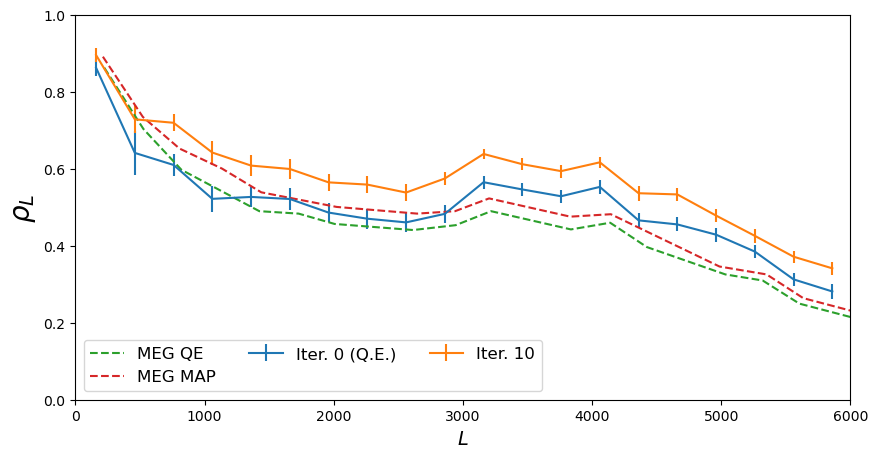

In [48]:
ell, = np.where(itlib.lib_qlm.get_Nell()[:lmax_qlm+1])
w = lambda ell : ell ** 2 * (ell + 1.) ** 2 /2./np.pi * 1e7

edges = np.arange(10, lmax_qlm+100, 300)
# edges = np.geomspace(10, lmax_qlm, 100).astype('int')
bl = edges[:-1];bu = edges[1:] 
ellb = 0.5 * bl + 0.5 * bu
cppfid = li.get_fidcls()[0]['pp']

bnd_cl = lambda cl : misc.misc_utils.binned(cl, ell, bl, bu, return_err=True)

pl.figure(figsize= (10,5))

ls = {'T':'--', 'QU':'-.', 'TQU':'-'}
c = {0:'C0', itmax:'C1'}
for it in [0, itmax]:
    cl = itlib.lib_qlm.alm2cl(itlib.get_Plm(it, 'p'))
    cl_in = itlib.lib_qlm.alm2cl(plm_input)
    cl_itin = itlib.lib_qlm.alm2cl(itlib.get_Plm(it, 'p'), plm_input)
    corr = cl_itin * np.sqrt(cli(cl * cl_in))
    corr_b, err = bnd_cl(corr)
    pl.errorbar(ellb, corr_b, yerr=err, label=f'Iter. %s'%it + (it == 0) * ' (Q.E.)')

    
pl.plot(meg_qe[0], meg_qe[1], ls='--', label='MEG QE')

pl.plot(meg_map[0], meg_map[1], ls='--', label='MEG MAP')

pl.ylabel(r'$\rho_L$', fontsize=20)
pl.xlabel(r'$L$', fontsize=14)
pl.legend(ncol=3, fontsize=12, loc='lower left')
pl.xlim(0, 6000)
pl.ylim(0, 1)
